## Import necessary libraries

In [2]:
import pandas as pd 
import numpy as np

import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.arima_model import ARMA
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.ardl import ARDL
from mlxtend.feature_selection import SequentialFeatureSelector
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from pmdarima.arima import auto_arima

from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import acorr_breusch_godfrey
from statsmodels.stats.diagnostic import het_breuschpagan

### Import DataSet

In [3]:
df = pd.read_excel("Bulgaria Growth rates.xlsx", index_col=0)
df = df.dropna()
df_train = df.iloc[1:43]
df_train
test = df.iloc[42:]
test

,gdp,ipr,fixed,unemp,cpi,sentiment,exchange_rate
quarters,,,,,,,
2010-10-01,0.009913,0.010044,0.014782,0.169811,0.010006,0.062242,0.012671
2011-01-01,0.000550,0.039777,-0.031488,0.061828,0.016511,-0.033180,0.005408
2011-04-01,0.009629,-0.003060,0.005609,-0.070886,0.003215,0.000365,0.009566
2011-07-01,0.000974,-0.007291,0.017766,-0.073569,0.001102,0.007299,-0.004504
2011-10-01,-0.000946,-0.010823,-0.010995,0.100000,0.004368,0.004710,-0.004119
2012-01-01,0.006563,-0.017194,0.026274,0.114973,0.010027,-0.025965,-0.015723
2012-04-01,-0.002509,0.036978,-0.009872,-0.040767,0.002761,0.021474,-0.001027
2012-07-01,-0.002357,-0.003451,-0.016548,-0.057500,0.012489,0.010149,0.006261
2012-10-01,-0.003169,-0.007311,-0.016639,0.068966,0.002914,-0.018299,0.008837


In [4]:
df.describe()

,gdp,ipr,fixed,unemp,cpi,sentiment,exchange_rate
count,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000
mean,0.008467,0.006904,0.012887,-0.009605,0.008919,0.003121,0.005288
std,0.009706,0.026910,0.048361,0.096832,0.013973,0.037379,0.012837
min,-0.044092,-0.122933,-0.207156,-0.150307,-0.018943,-0.141557,-0.022496
25%,0.006010,-0.007301,-0.004498,-0.071526,-0.000579,-0.013109,-0.003560
50%,0.009629,0.008163,0.011597,-0.033981,0.004471,0.005216,0.004443
75%,0.014052,0.021911,0.024184,0.046957,0.015090,0.019888,0.011797
max,0.021300,0.078598,0.275527,0.483444,0.045834,0.127939,0.044969


In [5]:
columns = df.columns.values.tolist()

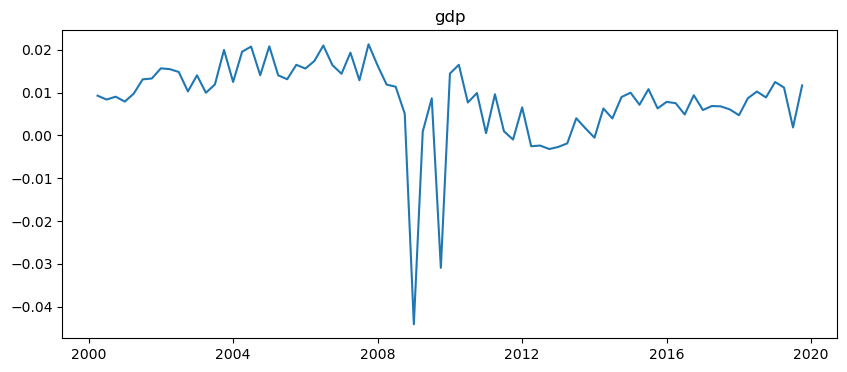

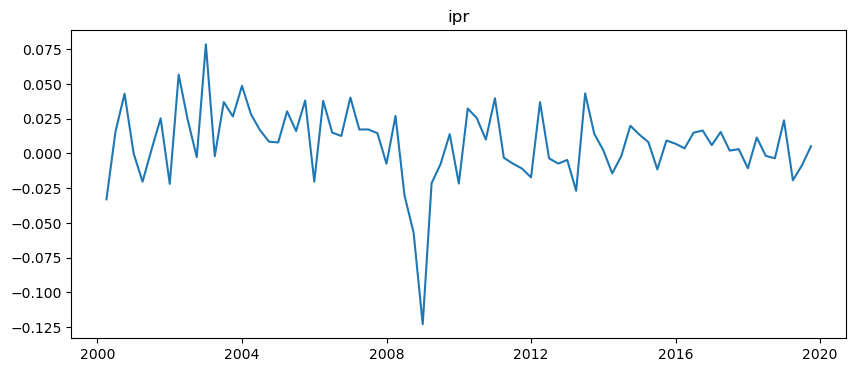

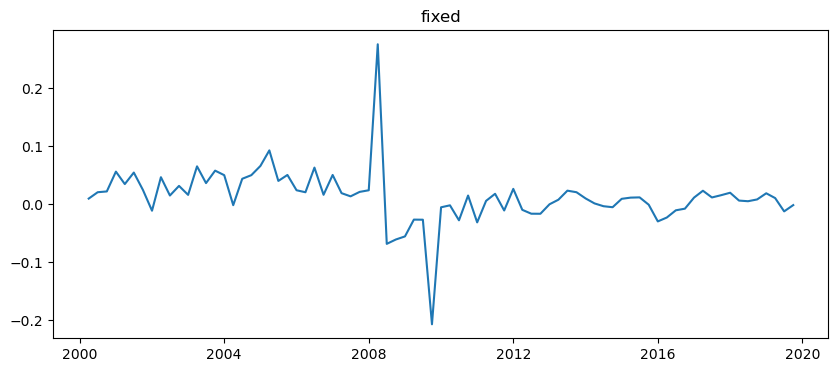

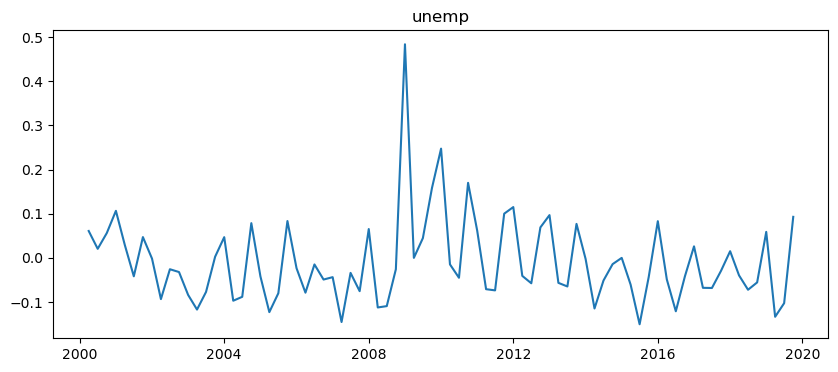

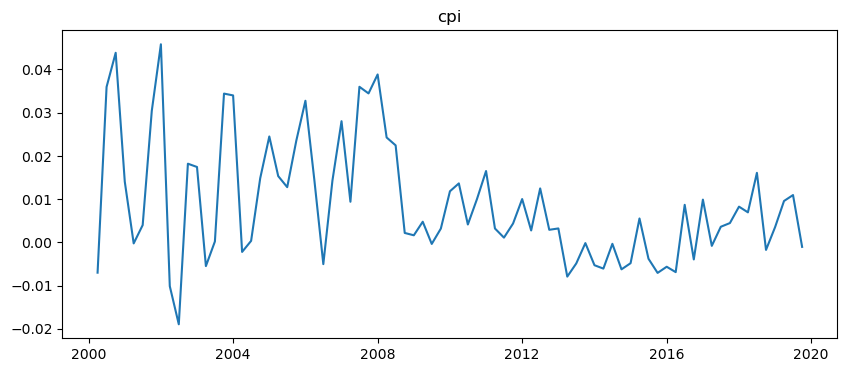

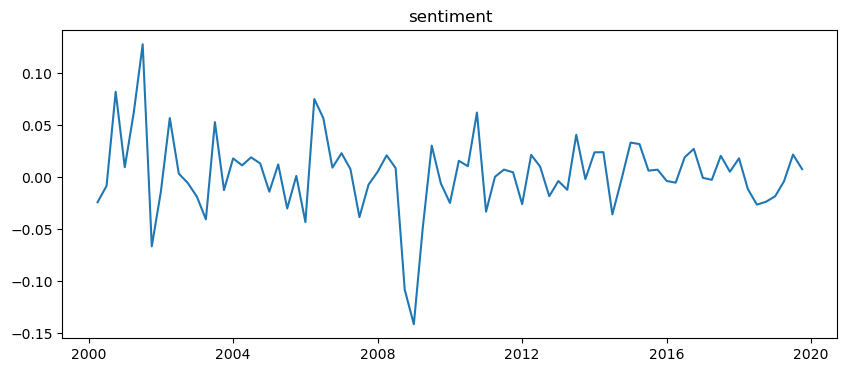

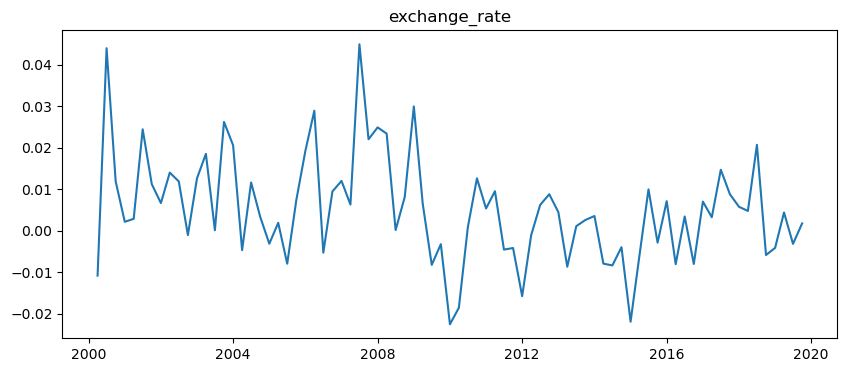

In [6]:
for x in columns:
    plt.figure(figsize=(10, 4))
    plt.plot(df.index, df[f'{x}'])
    plt.title(f'{x}')
    plt.show()

### Autocorrelation

C:\Users\lui-f\anaconda3\lib\site-packages\statsmodels\graphics\tsaplots.py:348: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  warnings.warn(


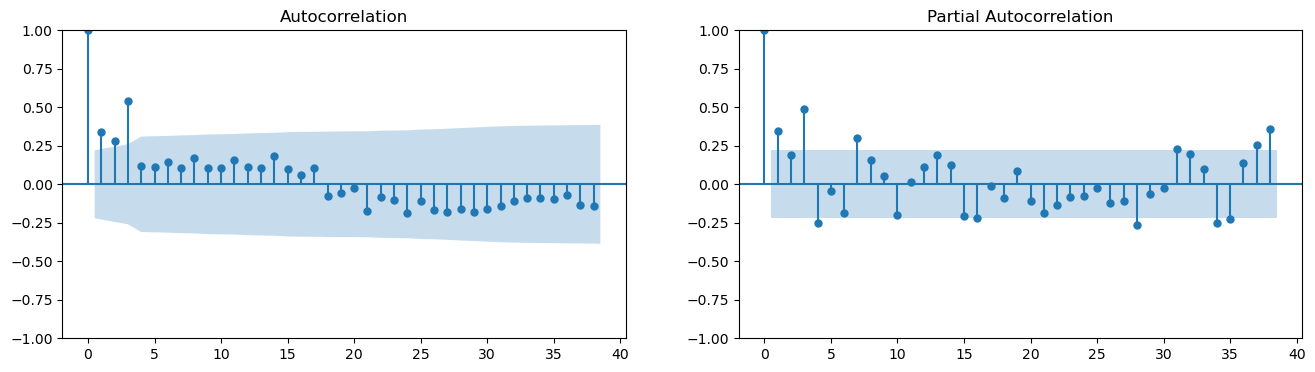

In [7]:
fig, axes = plt.subplots(1,2,figsize=(16,4), dpi= 100)
plot_acf(df['gdp'], lags=38, ax=axes[0])
plot_pacf(df['gdp'], lags=38, ax=axes[1])
plt.show()

### Build models

### OLS

In [8]:
y = df_train['gdp']
x = sm.add_constant(df_train[['ipr', 'fixed','unemp', 'cpi', 'sentiment', 'exchange_rate']])

In [9]:
model1 = sm.OLS(y, x).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                    gdp   R-squared:                       0.672
Model:                            OLS   Adj. R-squared:                  0.616
Method:                 Least Squares   F-statistic:                     11.96
Date:                Mon, 27 May 2024   Prob (F-statistic):           2.87e-07
Time:                        10:26:57   Log-Likelihood:                 150.10
No. Observations:                  42   AIC:                            -286.2
Df Residuals:                      35   BIC:                            -274.0
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.0085      0.002      5.032

In [10]:
#Tests
bg_test = acorr_breusch_godfrey(model1, nlags=1) 
print("BG test statistic:", bg_test[0])
print("P-value:", bg_test[1])

residuals = model1.resid
statistic, p_value = jarque_bera(residuals)
print("Jarque-Bera statistic:", statistic)
print("P-value:", p_value)

bp_test = het_breuschpagan(residuals, model1.model.exog)
print("Breusch-Pagan Test Statistic:", bp_test[0])
print("P-value:", bp_test[1])

BG test statistic: 1.7094598230686058
P-value: 0.1910554706930111
Jarque-Bera statistic: 13.64637683579641
P-value: 0.0010882456030801846
Breusch-Pagan Test Statistic: 4.7719681489662635
P-value: 0.5733748939514973


### ARDL (1,1)

In [17]:
model2 = ARDL(y, lags=1, exog=x, order=1).fit()
print(model2.summary())

                                   ARDL Model Results                                   
Dep. Variable:                              gdp   No. Observations:                   42
Model:             ARDL(1, 1, 1, 1, 1, 1, 1, 1)   Log Likelihood                 151.796
Method:                         Conditional MLE   S.D. of innovations              0.006
Date:                          Mon, 27 May 2024   AIC                           -269.591
Time:                                  10:28:33   BIC                           -240.461
Sample:                              10-01-2000   HQIC                          -258.984
                                   - 10-01-2010                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.0035      0.001      4.494      0.000       0.002       0.005
gdp.L1              -0.2290      

C:\Users\lui-f\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)


In [43]:
residuals = model2.resid
statistic, p_value = jarque_bera(residuals)
print("Jarque-Bera statistic:", statistic)
print("P-value:", p_value)

bp_test = het_breuschpagan(residuals, model2.model.exog[:41])
print("Breusch-Pagan Test Statistic:", bp_test[0])
print("P-value:", bp_test[1])

Jarque-Bera statistic: 21.717600540354212
P-value: 1.9234591291050762e-05
Breusch-Pagan Test Statistic: 1.537470038115122
P-value: 0.9569668111141332


### Independent variables without constant

In [14]:
x1 = df_train[['ipr', 'fixed','unemp', 'cpi', 'sentiment', 'exchange_rate']]

### Looking for the best model parameters

In [16]:
model = auto_arima(y, trace=True, error_action='ignore', suppress_warnings=True)
model.fit(y)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=-250.498, Time=0.08 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=-249.369, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=-249.948, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=-249.923, Time=0.01 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=-224.483, Time=0.00 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=-251.917, Time=0.03 sec
 ARIMA(0,0,2)(0,0,0)[0] intercept   : AIC=-249.168, Time=0.02 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=-249.943, Time=0.03 sec
 ARIMA(1,0,3)(0,0,0)[0] intercept   : AIC=-264.407, Time=0.05 sec
 ARIMA(0,0,3)(0,0,0)[0] intercept   : AIC=-266.382, Time=0.03 sec
 ARIMA(0,0,4)(0,0,0)[0] intercept   : AIC=-264.300, Time=0.04 sec
 ARIMA(1,0,4)(0,0,0)[0] intercept   : AIC=inf, Time=0.05 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=inf, Time=0.03 sec

Best model:  ARIMA(0,0,3)(0,0,0)[0] intercept
Total fit time: 0.396 seconds


ARIMA(order=(0, 0, 3), scoring_args={}, suppress_warnings=True)

### ARMA(0,3)

In [17]:
model3 = ARIMA(y, exog=x1, order=(0,0,3)).fit()
print(model3.summary())

                               SARIMAX Results                                
Dep. Variable:                    gdp   No. Observations:                   42
Model:                 ARIMA(0, 0, 3)   Log Likelihood                 151.994
Date:                Mon, 27 May 2024   AIC                           -281.988
Time:                        10:23:10   BIC                           -262.874
Sample:                    07-01-2000   HQIC                          -274.982
                         - 10-01-2010                                         
Covariance Type:                  opg                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.0076      0.002      4.100      0.000       0.004       0.011
ipr               0.0430      0.080      0.541      0.588      -0.113       0.199
fixed             0.0495      0.014     

/Users/nikita/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/Users/nikita/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/Users/nikita/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/Users/nikita/anaconda3/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [18]:
#Tests
bg_test = acorr_breusch_godfrey(model3, nlags=1) 
print("BG test statistic:", bg_test[0])
print("P-value:", bg_test[1])

residuals = model3.resid
statistic, p_value = jarque_bera(residuals)
print("Jarque-Bera statistic:", statistic)
print("P-value:", p_value)

bp_test = het_breuschpagan(residuals, model3.model.exog)
print("Breusch-Pagan Test Statistic:", bp_test[0])
print("P-value:", bp_test[1])

BG test statistic: 0.847861414190481
P-value: 0.3571580381106281
Jarque-Bera statistic: 12.501429446932356
P-value: 0.0019290748883053076
Breusch-Pagan Test Statistic: 4.5757895886936115
P-value: 0.5992514464247194


### AR(2)

In [28]:
model4 = sm.tsa.ARIMA(y, exog = x1, order=(2,0, 0)).fit()
print(model4.summary())

                               SARIMAX Results                                
Dep. Variable:                    gdp   No. Observations:                   42
Model:                 ARIMA(2, 0, 0)   Log Likelihood                 152.042
Date:                Mon, 27 May 2024   AIC                           -284.083
Time:                        10:33:36   BIC                           -266.706
Sample:                    07-01-2000   HQIC                          -277.714
                         - 10-01-2010                                         
Covariance Type:                  opg                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.0077      0.002      5.123      0.000       0.005       0.011
ipr               0.0567      0.067      0.847      0.397      -0.074       0.188
fixed             0.0487      0.013     

C:\Users\lui-f\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
C:\Users\lui-f\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
C:\Users\lui-f\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
C:\Users\lui-f\anaconda3\lib\site-packages\statsmodels\base\model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [29]:
bg_test = acorr_breusch_godfrey(model4, nlags=1) 
print("BG test statistic:", bg_test[0])
print("P-value:", bg_test[1])

residuals = model4.resid
statistic, p_value = jarque_bera(residuals)
print("Jarque-Bera statistic:", statistic)
print("P-value:", p_value)

bp_test = het_breuschpagan(residuals, model4.model.exog)
print("Breusch-Pagan Test Statistic:", bp_test[0])
print("P-value:", bp_test[1])

BG test statistic: 0.8901707755308192
P-value: 0.3454310335585966
Jarque-Bera statistic: 13.161297564774028
P-value: 0.0013869491746801854
Breusch-Pagan Test Statistic: 4.1725115077999
P-value: 0.6533436856029162


## Forecast

In [101]:
xf = test[['ipr', 'fixed','unemp', 'cpi', 'sentiment', 'exchange_rate']]

In [102]:
forecast_steps = 37
forecast = model3.get_forecast(steps=forecast_steps, exog = xf)
forecast_conf_int = forecast.conf_int()
forecast_mean = forecast.predicted_mean

## Evaluating model

In [103]:
mae = mean_absolute_error(test['gdp'], forecast_mean)
mse = mean_squared_error(test['gdp'], forecast_mean)
rmse = np.sqrt(mse)

In [104]:
print(f'Mean Absolute Error (MAE): {mae}')
print(f'Mean Squared Error (MSE): {mse}')
print(f'Root Mean Squared Error (RMSE): {rmse}')

Mean Absolute Error (MAE): 0.005659124517092754
Mean Squared Error (MSE): 4.745132560265703e-05
Root Mean Squared Error (RMSE): 0.006888492259025702


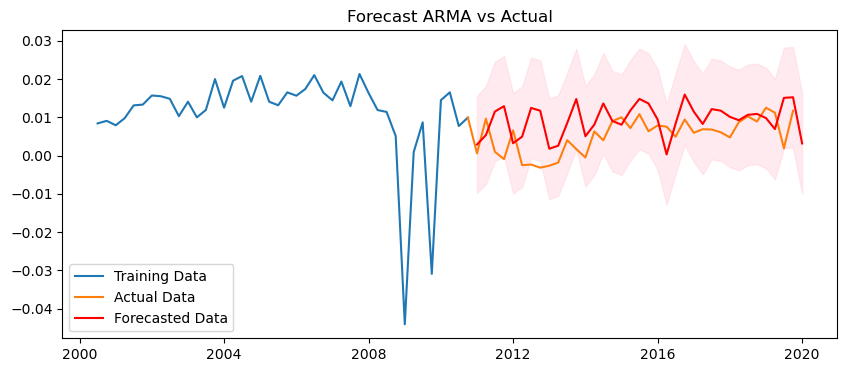

In [105]:
plt.figure(figsize=(10, 4))
plt.plot(df_train.index, df_train['gdp'], label='Training Data')
plt.plot(test.index, test['gdp'], label='Actual Data')
plt.plot(forecast_mean.index, forecast_mean, label='Forecasted Data', color='red')
plt.fill_between(forecast_conf_int.index, forecast_conf_int.iloc[:, 0], forecast_conf_int.iloc[:, 1], color='pink', alpha=0.3)
plt.title('Forecast ARMA vs Actual')
plt.legend()
plt.savefig('boxplot.png')

In [106]:
forecast_steps = 37
forecast1 = model4.get_forecast(steps=forecast_steps, exog = xf)
forecast_conf_int1 = forecast1.conf_int()
forecast_mean1 = forecast1.predicted_mean

In [107]:
mae1 = mean_absolute_error(test['gdp'], forecast_mean1)
mse1 = mean_squared_error(test['gdp'], forecast_mean1)
rmse1 = np.sqrt(mse1)

In [108]:
print(f'Mean Absolute Error (MAE): {mae1}')
print(f'Mean Squared Error (MSE): {mse1}')
print(f'Root Mean Squared Error (RMSE): {rmse1}')

Mean Absolute Error (MAE): 0.005766770505022908
Mean Squared Error (MSE): 4.927294590688722e-05
Root Mean Squared Error (RMSE): 0.0070194690616090915


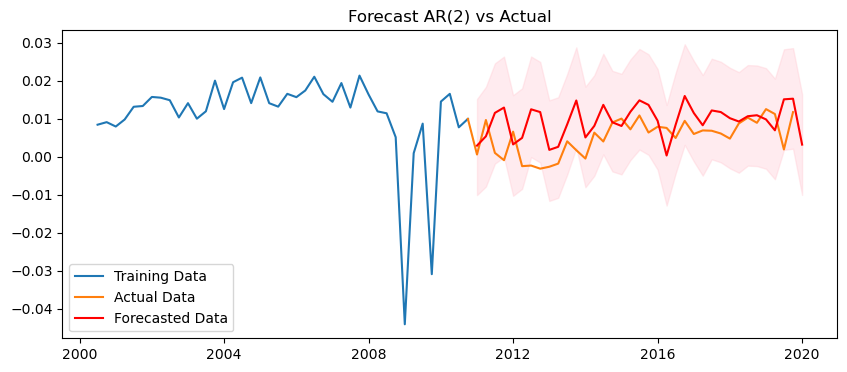

In [109]:
plt.figure(figsize=(10, 4))
plt.plot(df_train.index, df_train['gdp'], label='Training Data')
plt.plot(test.index, test['gdp'], label='Actual Data')
plt.plot(forecast_mean1.index, forecast_mean, label='Forecasted Data', color='red')
plt.fill_between(forecast_conf_int1.index, forecast_conf_int1.iloc[:, 0], forecast_conf_int1.iloc[:, 1], color='pink', alpha=0.3)
plt.title('Forecast AR(2) vs Actual')
plt.legend()
plt.savefig('boxplot1.png')

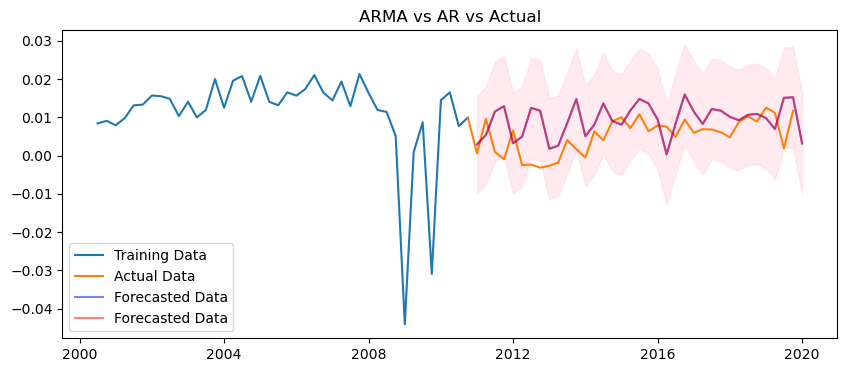

In [110]:
plt.figure(figsize=(10, 4))
plt.plot(df_train.index, df_train['gdp'], label='Training Data')
plt.plot(test.index, test['gdp'], label='Actual Data')
plt.plot(forecast_mean1.index, forecast_mean, label='Forecasted Data', color='blue', alpha= 0.5)
plt.plot(forecast_mean.index, forecast_mean, label='Forecasted Data', color='red', alpha = 0.5)
plt.fill_between(forecast_conf_int.index, forecast_conf_int.iloc[:, 0], forecast_conf_int.iloc[:, 1], color='pink', alpha=0.3)

plt.title('ARMA vs AR vs Actual')
plt.legend()
plt.savefig('boxplot2.png')